<a href="https://colab.research.google.com/github/WeizmannMLcourse/MLCourse_2025/blob/main/Tutorial8_GNN/Molecule_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Molecule property regression with message-passing network

## Colab

### Prerequisite: Install appropriate PyTorch and PyTorch Geometric versions

- `torch`: https://pytorch.org/get-started/previous-versions/#v240
- `PyG`: https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset
import torch
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
import torch_geometric.transforms as T
from tqdm import tqdm

/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
%load_ext autoreload
%autoreload 2

## QM9 dataset
PyTorch Geometric provides a preloaded interface to this dataset of 130k molecules.
- https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.QM9.html
- http://quantum-machine.org/datasets/

We want to train a graph neural network to regress the magnitude of the electric dipole moment $|\vec{\mu}|$ of the molecule, where:

$\vec{\mu} = \sum_{i} q_i \vec{x_i}$

The atoms (nodes) in each molecule (graph) contain the following features:
- `pos`: spatial coordinates (3 numbers)
- `x`: additional properties (11 numbers)

For our task, we will restrict ourselves to _purely_ the spatial coordinates and the atomic number as input features.

In [3]:
data = QM9(root='data/QM9')

In [4]:
len(data)

130831

In [5]:
g = data.__getitem__(100000)
labels = g.y[:, 0].unsqueeze(-1)

## Plotly visualization
Code in `visualizer.py`

In [6]:
from visualizer import draw_plotly
draw_plotly(g)

/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## Message-passing model
This simple graph neural network consists of three main network components:
1) Node feature encoding
2) Message passing blocks
3) Graph-level prediction

<img src="model.jpeg">

In [7]:
from model import MoleculeMPNN

In [8]:
net = MoleculeMPNN()

In [9]:
### number of parameters ###
sum(p.numel() for p in net.parameters())

371969

### Train-val-test splits

In [10]:
### we can apply 3D random rotation as a data-augmentation to improve generalization
train_transform = T.Compose([
    T.RandomRotate(180, axis=0),
    T.RandomRotate(180, axis=1),
    T.RandomRotate(180, axis=2),
])
rotated_data = QM9(root='data/QM9', transform=train_transform)

train_dataset = torch.utils.data.Subset(rotated_data, range(100000))
valid_dataset = torch.utils.data.Subset(rotated_data, range(100000,105000))
test_dataset  = torch.utils.data.Subset(data,         range(110000,len(data)-1))

bs = 256
if (torch.cuda.is_available() or \
     (hasattr(torch.backends, 'mps') and torch.backends.mps.is_available())):
    bs = 1024

train_dataloader = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=0)
valid_dataloader = DataLoader(valid_dataset, batch_size=bs, num_workers=0)
test_dataloader  = DataLoader(test_dataset,  batch_size=1, num_workers=0)

In [11]:
print(g.x.shape, g.z.shape)

torch.Size([18, 11]) torch.Size([18])


In [12]:
net(g)

tensor([[0.0119]], grad_fn=<AddmmBackward0>)

In [13]:
### Loop through dataset to find range of z values
z_values = set()
for g in tqdm(data):
    z_values.update(g.z.tolist())
print("Unique z values:", sorted(z_values))

100%|██████████| 130831/130831 [00:08<00:00, 15563.57it/s]

Unique z values: [1, 6, 7, 8, 9]


## Training

In [14]:
from training import train_valid_loop

train_loss, valid_loss = train_valid_loop(net, train_dataloader, valid_dataloader, 100)

Found Apple MPS!


  1%|          | 1/100 [00:41<1:08:34, 41.56s/it]

Epoch:  0  Train loss:  3.2602005394137636  Valid loss:  2.4402530670166014


  2%|▏         | 2/100 [01:17<1:02:21, 38.18s/it]

Epoch:  1  Train loss:  2.635015373327294  Valid loss:  2.016892838478088


...

Epoch:  58  Train loss:  0.5385654553466913  Valid loss:  0.5709147036075592


 60%|██████    | 60/100 [49:24<1:22:36, 123.92s/it]

Epoch:  59  Train loss:  0.5168877411253598  Valid loss:  0.5812904179096222


 60%|██████    | 60/100 [52:23<34:55, 52.39s/it]   


KeyboardInterrupt: 

In [15]:
### Optional reload of stored values if they exist ###
import os
if os.path.exists('train_loss.npy') and os.path.exists('valid_loss.npy'):
    train_loss = np.load('train_loss.npy')
    valid_loss = np.load('valid_loss.npy')

In [16]:
### Optional load of a saved model if it exists ###
import os
if os.path.exists('saved_model.pt'):
    net.load_state_dict(torch.load('saved_model.pt', map_location=torch.device('cpu')))

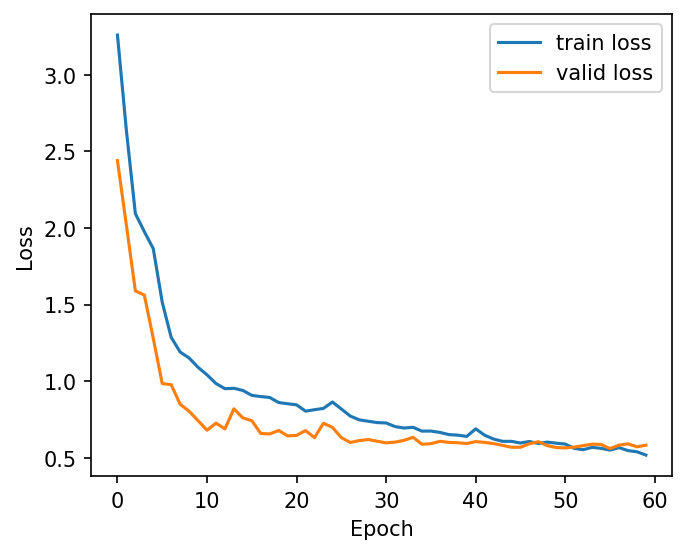

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(5,4), dpi=150)
ax.plot(range(len(train_loss)),train_loss,label='train loss')
ax.plot(range(len(valid_loss)),valid_loss,label='valid loss')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

## Performance evaluation

In [19]:
net = net.eval().cpu()

preds, trues = [], []

for i in tqdm(range(len(test_dataset))):
    g = test_dataset.__getitem__(i)
    preds.append(net(g).detach().numpy().item())
    trues.append(g.y[:, 0].item())

preds = np.array(preds)
trues = np.array(trues)

100%|██████████| 20830/20830 [00:13<00:00, 1510.29it/s]


### Predicted vs. true 2D density plot

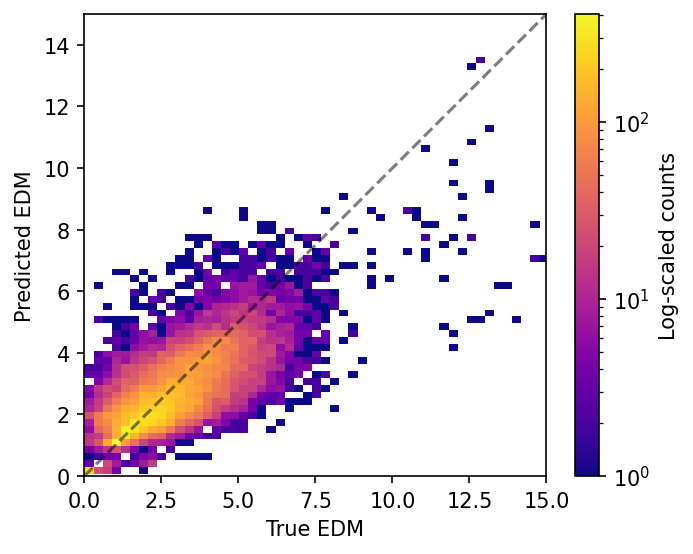

In [20]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(1, 1, figsize=(5,4), dpi=150)
h = ax.hist2d(
    trues,
    preds,
    bins=100,
    cmap='plasma',
    norm=LogNorm(),  # Apply log normalization
    cmin=1
)
fig.colorbar(h[3], ax=ax, label='Log-scaled counts')
ax.plot([0, 15], [0, 15], c='black', ls='--', alpha=0.5)
ax.set_xlabel('True EDM')
ax.set_ylabel('Predicted EDM')
ax.set_xlim(0, 15)
ax.set_ylim(0, 15)
ax.set_aspect('equal')

### Residual distribution

Text(0.5, 0, '(pred - true) / true')

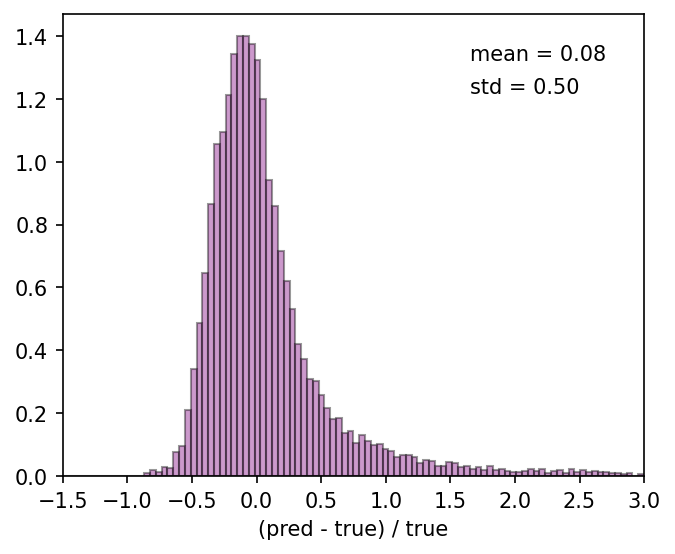

: 

In [ ]:
resids = (preds-trues)/(trues+1e-6)
resids = resids[abs(resids) < 3]

fig, ax = plt.subplots(1, 1, figsize=(5,4), dpi=150)
h = ax.hist(resids, bins=100, range=(-1.5,3), facecolor='purple', alpha=0.4, density=True, lw=1, edgecolor='black')
ax.set_xlim(-1.5, 3)
ax.text(0.7, 0.90, 'mean = {:.2f}'.format(np.mean(resids)), transform=ax.transAxes)
ax.text(0.7, 0.83, 'std = {:.2f}'.format(np.std(resids)), transform=ax.transAxes)
ax.set_xlabel('(pred - true) / true')